# Hotel Booking Demand Cancellation Prediction
### Capstone Notebook

**Oleh: Ikhsani Taufiqullah Hasan**

## Business Problem Understanding

**Context**  
Hotel di Portugal menerima ribuan booking dari berbagai negara dan channel. Sebagian booking pada akhirnya dibatalkan, sehingga kamar kosong, forecast okupansi menjadi tidak akurat, dan tim operasional kehilangan waktu untuk menangani booking yang sebenarnya berisiko tinggi.

**Stakeholders**
- Revenue manager: ingin mengurangi kehilangan pendapatan akibat pembatalan.
- Reservation team: ingin memprioritaskan booking yang perlu di-follow up.
- Operations team: ingin perencanaan kamar, housekeeping, dan staffing yang lebih akurat.
- Marketing / CRM team: ingin memahami segmen pelanggan yang paling berisiko cancel.

**Target**
- `0` = booking tidak dibatalkan
- `1` = booking dibatalkan

**Problem Statement**

Proses booking hotel rawan pembatalan dan tidak efisien bila semua booking diperlakukan sama. Hotel perlu mengetahui booking mana yang berisiko cancel sehingga tim bisa fokus melakukan intervensi hanya pada booking yang paling berpotensi dibatalkan.

**Goals**
- Memprediksi probabilitas booking akan dibatalkan atau tidak.
- Mengurangi beban review manual booking.
- Meningkatkan okupansi dan akurasi perencanaan.
- Memberi dasar kebijakan bisnis seperti deposit policy, penyesuaian harga, atau follow-up tambahan untuk booking berisiko.

**Analytic Approach**
Kita akan menganalisis data untuk menemukan pola pembeda antara booking cancel dan non-cancel, lalu membangun model klasifikasi untuk memprediksi risiko pembatalan.

**Metric Evaluation**

Dalam kasus ini, kesalahan prediksi tidak memiliki dampak yang sama.

- **False Positive**: booking diprediksi cancel padahal tidak cancel. Dampaknya adalah effort follow-up yang kurang efisien.
- **False Negative**: booking diprediksi tidak cancel padahal cancel. Dampaknya lebih serius karena hotel kehilangan kesempatan mitigasi.

Karena konsekuensi bisnis dari booking cancel yang lolos lebih besar, **Recall untuk kelas `1` (cancel)** menjadi metrik utama.  
Sebagai metrik pendukung, kita tetap lihat **Precision**, **F1-score**, **ROC AUC**, dan **PR AUC** agar model tidak hanya agresif menandai cancel tanpa kualitas yang baik.

___

## Data Understanding

Dataset ini berisi booking hotel per baris data. Fitur yang digunakan pada notebook ini adalah:

| Attribute | Data Type, Length | Description |
| --- | --- | --- |
| country | Text | Country of origin |
| market_segment | Text | Market segment designation |
| previous_cancellations | Int | Number of previous bookings that were cancelled by the customer prior to the current booking |
| booking_changes | Int | Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation |
| deposit_type | Text | Indication on if the customer made a deposit to guarantee the booking |
| days_in_waiting_list | Int | Number of days the booking was in the waiting list before it was confirmed to the customer |
| customer_type | Text | Type of booking |
| reserved_room_type | Text | Code of room type reserved |
| required_car_parking_space | Int | Number of car parking spaces required by the customer |
| total_of_special_request | Int | Number of special requests made by the customer (e.g. twin bed or high floor) |
| is_canceled | Binary | 0: Booking was not canceled, 1: Booking was canceled |


Catatan penting:
- Sebagian fitur bersifat kategorikal nominal, sehingga encoding perlu dipilih dengan hati-hati.
- Target berpotensi tidak seimbang, jadi akurasi saja tidak cukup untuk evaluasi.

In [1]:
# Data Analysis
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from IPython.display import display
import plotly.express as px

# Feature Engineering
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

# Save Model
import joblib

# Silence Warnings
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 5)

data_path = 'data_hotel_booking_demand.csv'

df_raw = pd.read_csv(data_path)
print(f'Dataset loaded from: {data_path}')
print(f'Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}')
display(df_raw.head())
print('\nInfo awal dataset:')
df_raw.info()

def dataframe_profile(df):
    rows = []
    for col in df.columns:
        sample_values = list(df[col].dropna().astype(str).drop_duplicates().head(2))
        rows.append([
            col,
            df[col].dtype,
            int(df[col].isna().sum()),
            round(df[col].isna().mean() * 100, 2),
            int(df[col].nunique(dropna=True)),
            sample_values
        ])
    return pd.DataFrame(rows, columns=['feature', 'dtype', 'missing', 'missing_pct', 'n_unique', 'sample_values'])

print('\nProfil dataset:')
display(dataframe_profile(df_raw))

print('\nDistribusi target:')
display(df_raw['is_canceled'].value_counts().rename(index={0: 'not_canceled', 1: 'canceled'}))
print('Cancellation rate: {:.2f}%'.format(df_raw['is_canceled'].mean() * 100))

Dataset loaded from: data_hotel_booking_demand.csv
Rows: 83,573 | Columns: 11


,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0



Info awal dataset:
<class 'pandas.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   country                      83222 non-null  str  
 1   market_segment               83573 non-null  str  
 2   previous_cancellations       83573 non-null  int64
 3   booking_changes              83573 non-null  int64
 4   deposit_type                 83573 non-null  str  
 5   days_in_waiting_list         83573 non-null  int64
 6   customer_type                83573 non-null  str  
 7   reserved_room_type           83573 non-null  str  
 8   required_car_parking_spaces  83573 non-null  int64
 9   total_of_special_requests    83573 non-null  int64
 10  is_canceled                  83573 non-null  int64
dtypes: int64(6), str(5)
memory usage: 7.0 MB

Profil dataset:


,feature,dtype,missing,missing_pct,n_unique,sample_values
0,country,str,351,0.42,162,"[IRL, FRA]"
1,market_segment,str,0,0.00,8,"[Offline TA/TO, Online TA]"
2,previous_cancellations,int64,0,0.00,15,"[0, 1]"
3,booking_changes,int64,0,0.00,19,"[0, 1]"
4,deposit_type,str,0,0.00,3,"[No Deposit, Non Refund]"
5,days_in_waiting_list,int64,0,0.00,115,"[0, 3]"
6,customer_type,str,0,0.00,4,"[Transient-Party, Transient]"
7,reserved_room_type,str,0,0.00,10,"[A, E]"
8,required_car_parking_spaces,int64,0,0.00,5,"[0, 1]"
9,total_of_special_requests,int64,0,0.00,6,"[0, 2]"



Distribusi target:


is_canceled
not_canceled    52795
canceled        30778
Name: count, dtype: int64

Cancellation rate: 36.83%


___

## Data Cleaning

### Basic Cleaning

Pertama, lakukan prosedur basic data cleaning terlebih dahulu (standardization, remove index, drop duplicate, dll).

In [3]:
# Data Sanitation and Standardization
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()

if 'index' in df.columns:
    df = df.drop(columns=['index'])

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('string').str.strip()

df = df.replace({'': np.nan, ' ': np.nan})

df.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [4]:
print('\nDuplicate rows:', df_raw.duplicated().sum())


Duplicate rows: 73371


Terdapat 73371 rows yang duplicate, namun perlu diingat bahwa **semua informasi identitas pada raw data sudah dihapus**, termasuk unique identifier. Artinya tidak ada informasi yang menjelaskan apakah setiap baris yang duplicate tersebut adalah transaksi yang sama atau berbeda. Dalam hal ini, kita berasumsi bahwa setiap baris adalah transaksi tersendiri, sehingga menghapus semua 73371 rows yang duplicate **terlalu berisiko** menghilangkan sebagian besar data. Oleh karena itu, **`drop_duplicate()` tidak dilakukan**.

### Split Training and Test Data

Sebelum lanjut ke proses selanjutnya, data di-split terlebih dahulu antara training data dan test data agar tidak menimbulkan data leakage ke depannya.

In [5]:
x = df.drop(columns=['is_canceled'])
y = df['is_canceled']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Selanjutnya, kita akan memakai x_train dan y_train untuk data cleaning dan data analysis yang melibatkan data training.

### Inspect Missing Value

Tahap selanjutnya dalam data cleaning adalah memeriksa missing value yang mungkin terdapat dalam dataset. Memeriksa missing value bukan hanya tentang menghitung berapa banyak baris/kolom yang kosong, tetapi juga untuk memeriksa integritas data itu sendiri, seperti:
1. **Mengidentifikasi tipe missing data**
    
    Missing data umumnya diklasifikasi ke dalam 3 tipe:
    - **Missing Completely at Random (MCAR)**, kosongnya data terjadi secara random dan tidak ada hubungannya sama sekali dengan variabel manapun pada dataset, baik yang sudah diketahui maupun yang hilang (technical error).
    - **Missing at Random (MAR)**, kosongnya data memiliki hubungan pada variabel lain yang sudah kita miliki (observed) di dataset, tapi value mana yang kosong dari hubungan tersebut bersifat random (invisible pattern).
    - **Missing not at Random (MNAR)**, kosongnya data secara langsung berhubungan dengan value yang missing (intentionally left blank).
2. **Mengidentifikasi Selection Bias (Poor Survey)**
    
    Jika missing value hanya terdapat pada kelompok yang sangat spesifik, dan kita memilih untuk drop data yang mengandung missing value tersebut, maka ada potensi data menjadi tidak lengkap (skewed) dan conclusion menjadi berbeda dari situasi sebenarnya.

3. **Menentukan strategi untuk memperbaiki data** 

    Jika tipe missing data sudah bisa diperkirakan, maka selanjutnya kita bisa menentukan strategi untuk menangani missing value tersebut (drop, impute, atau flag kategori baru).

Reference:
- https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/
- https://www.datacamp.com/tutorial/techniques-to-handle-missing-data-values?utm_aid=157098106975&utm_loc=9074326-&utm_mtd=-c&utm_kw=&gad_campaignid=19589720824
- https://www.analyticsvidhya.com/blog/2021/10/handling-missing-value/#Types_of_Missing_Values

Untuk memulai pemeriksaan missing value, kita bisa menggunakan module missingno. Missingno merupakan library yang terdapat pada python yang menyediakan suatu cara untuk memahami, serta mengidentifikasi distribusi dari nilai yang hilang pada dataset secara visual. Visualisasi dari missingno dapat berupa heatmap, barplot, matrix dll. Dengan library ini memungkinkan untuk mengetahui hubungan antar missing value, letak missing value, serta jumlah dari missing value.

Reference:
- https://medium.com/@patiprabusultan/missingno-library-pada-python-untuk-membantu-mengidentifikasi-missing-value-3bafb9515b20

#### Bar Plot
Pertama, kita menggunakan Bar Plot untuk melihat _apakah ada_ missing value pada dataset tersebut, dan seberapa banyak jumlahnya.

<Axes: >

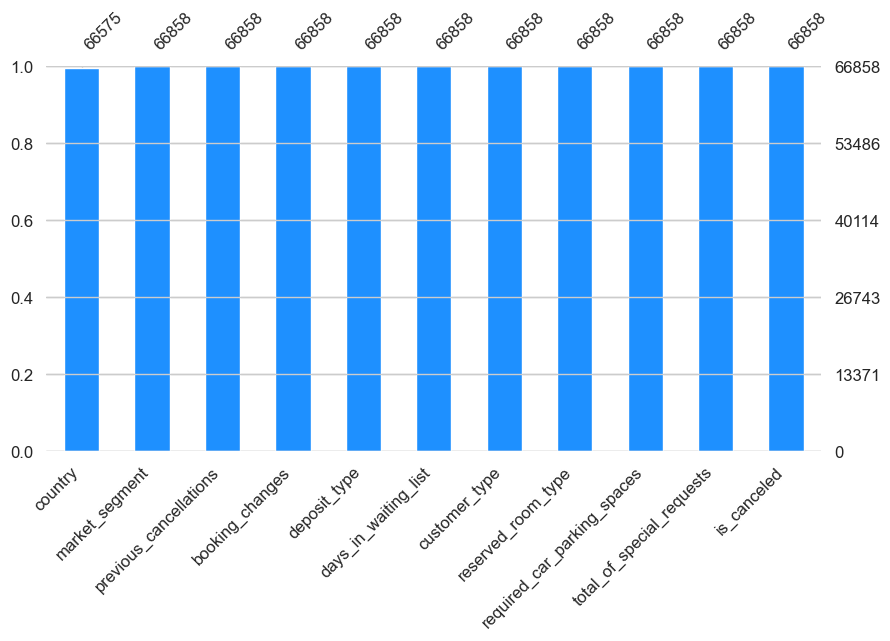

In [6]:
msno.bar(pd.concat([x_train, y_train], axis=1),color="dodgerblue", sort="ascending", figsize=(10,5), fontsize=12)

In [7]:
missing_value_country = x_train['country'].isnull().sum()
total_value_country = x_train['country'].count()
missing_value_country_ratio = missing_value_country / total_value_country
print(f'Rasio missing value pada feature country = {missing_value_country_ratio.round(4)*100}%')

Rasio missing value pada feature country = 0.43%


Terlihat bahwa hampir semua data sudah lengkap, hanya feature country yang memiliki missing value, itupun dalam jumlah yang sangat sedikit (0.43%).

### Strategy Selection
Selanjutnya, kita perlu memilih apa yang akan kita lakukan pada missing value tersebut.
Ada tiga strategi utama yang dipertimbangkan untuk menangani missing value (khususnya pada data kategorikal):

1. **Drop** rows/columns.
   - Kelebihan: Paling sederhana, paling aman dari bias imputasi.
   - Kekurangan: Beresiko membuang data yang mungkin masih berguna, terutama pada data imbalance.
   - Kapan digunakan: Jika baris/kolom tersebut memiliki terlalu banyak missing value, namun perlu inspeksi lebih mendalam jika data bersifat extreme imbalanced.

2. **Impute** mean/median/mode.
   - Kelebihan: Mempertahankan jumlah data point, mudah diimplementasikan.
   - Kekurangan: Mengabaikan konteks dan hubungan antar variabel, bisa menciptakan bias.
   - Kapan digunakan: Jika missing value bertipe MCAR dan jumlahnya relatif sedikit.

3. **Model-based Impute** with ML algorithm (regression, KNN, decision trees, etc).
   - Kelebihan: Lebih akurat dibanding Impute biasa, karena melibatkan konteks data (hubungan antar variabel).
   - Kekurangan: Lebih kompleks dan sensitif terhadap kualitas variabel lain, tidak efektif diaplikasikan pada variabel yang bersifat independen.
   - Kapan digunakan: Jika missing value bertipe MAR.

3. **Flagging** new category ("Undefined").
   - Kelebihan: Tidak menghapus ataupun merubah informasi.
   - Kekurangan:
      - Nominal Category -> Tidak terlalu penting jika jumlah missing value terlalu sedikit, karena bisa menambah dimensi data untuk peningkatan akurasi yang tidak signifikan.
      - Numerical Category -> Mayoritas model sklearn tidak bisa langsung menerima NaN.
   - Kapan digunakan: Jika ada tendensi missing value bertipe MNAR atau MAR, dan jumlahnya relatif banyak.
   
Reference:
https://binus.ac.id/malang/computer-science/2024/12/03/beberapa-cara-untuk-mengatasi-missing-value/

Karena kita telah mengetahui bahwa feature country menjadi satu-satunya feature yang tidak lengkap, dan ratio missing value dalam feature tersebut sangat kecil, artinya kita bisa mengeliminasi metode Drop rows/columns.

Note: Kita boleh saja menggunakan metode Drop rows/columns, tapi berhubung metode Impute mean/median/mode juga mudah diimplementasikan, maka tidak ada salahnya mengutamakan Impute di atas Drop row/columns, terlebih dengan resiko bias yang kecil (karena missing value yang sangat sedikit).

### Matrix Plot

<Axes: >

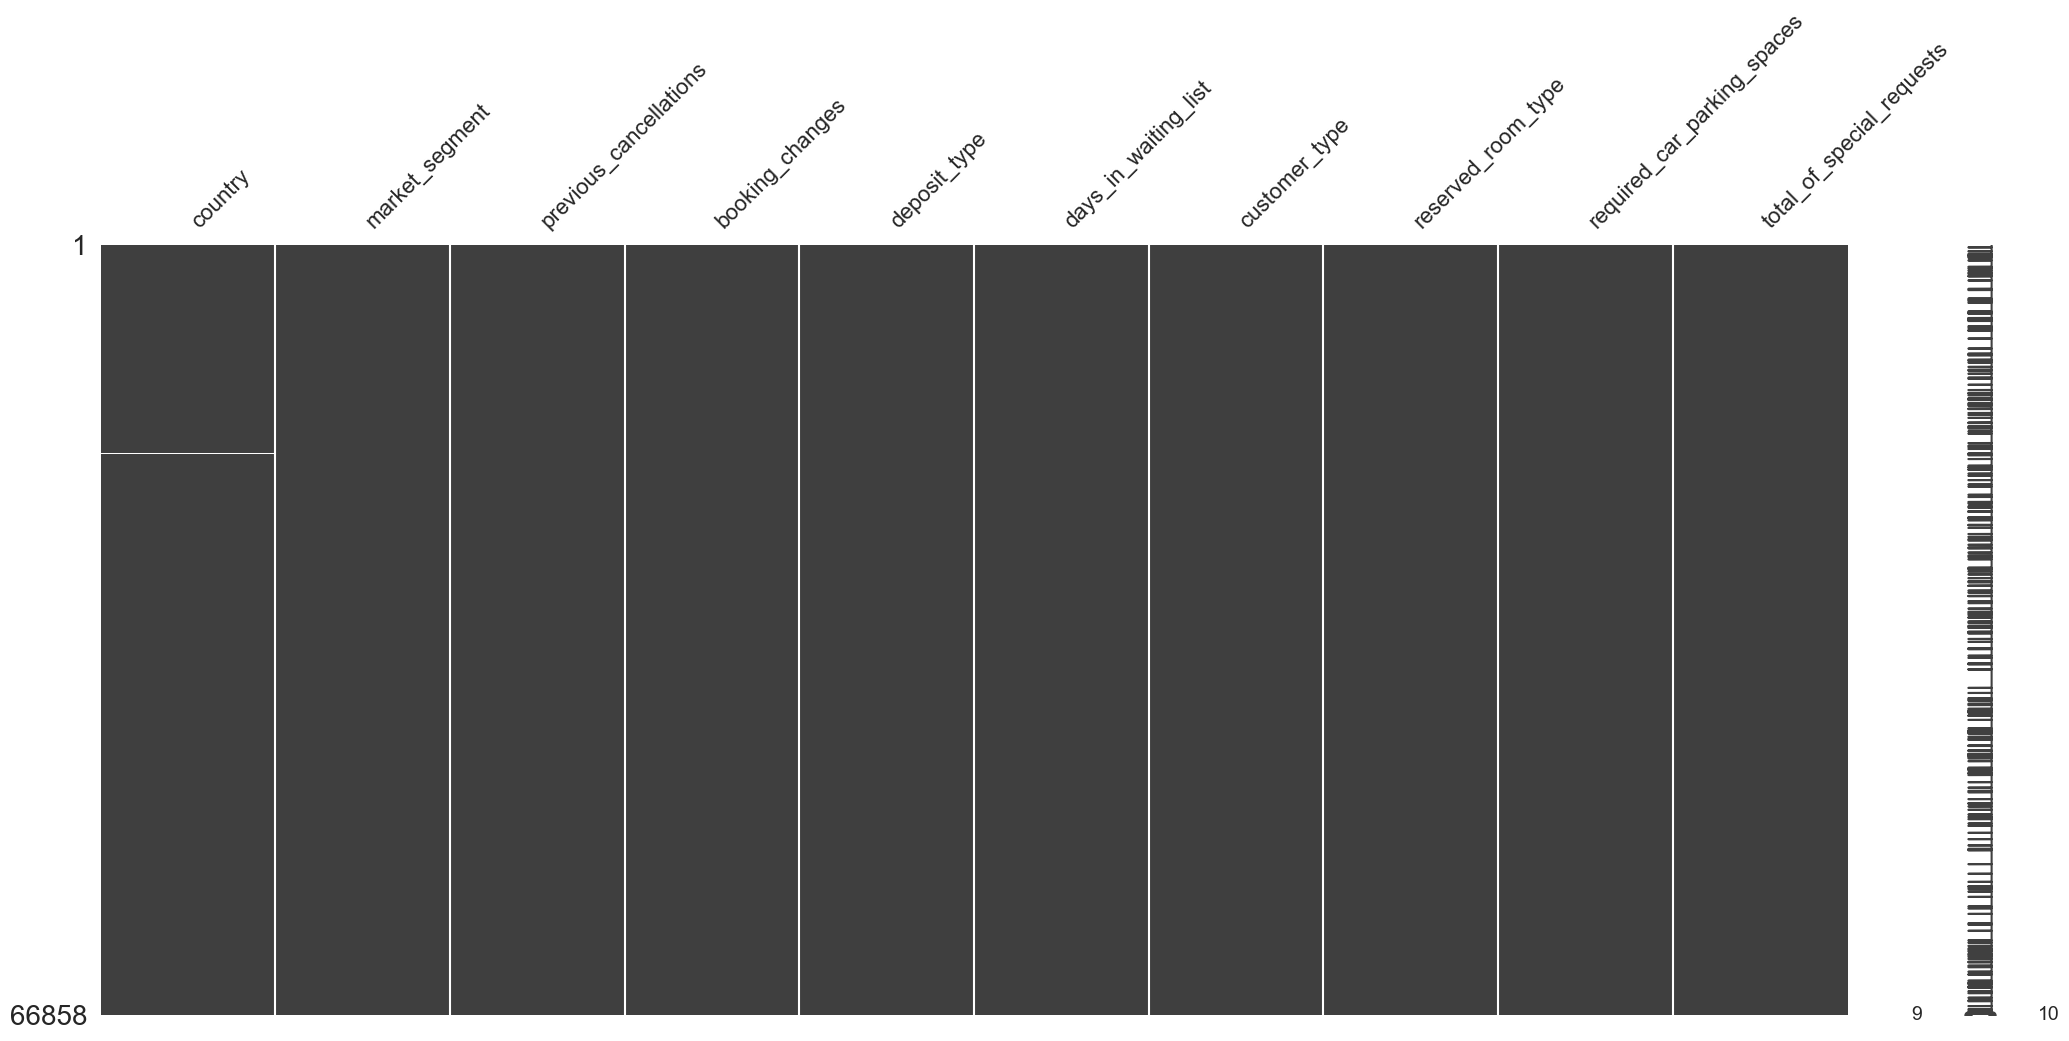

In [8]:
msno.matrix(x_train)

Terlihat bahwa missing value tidak memiliki pola atau segmen khusus (acak). Tidak ada hubungan yang menunjukkan bahwa missing value terjadi karena intentionally left blank (MNAR).

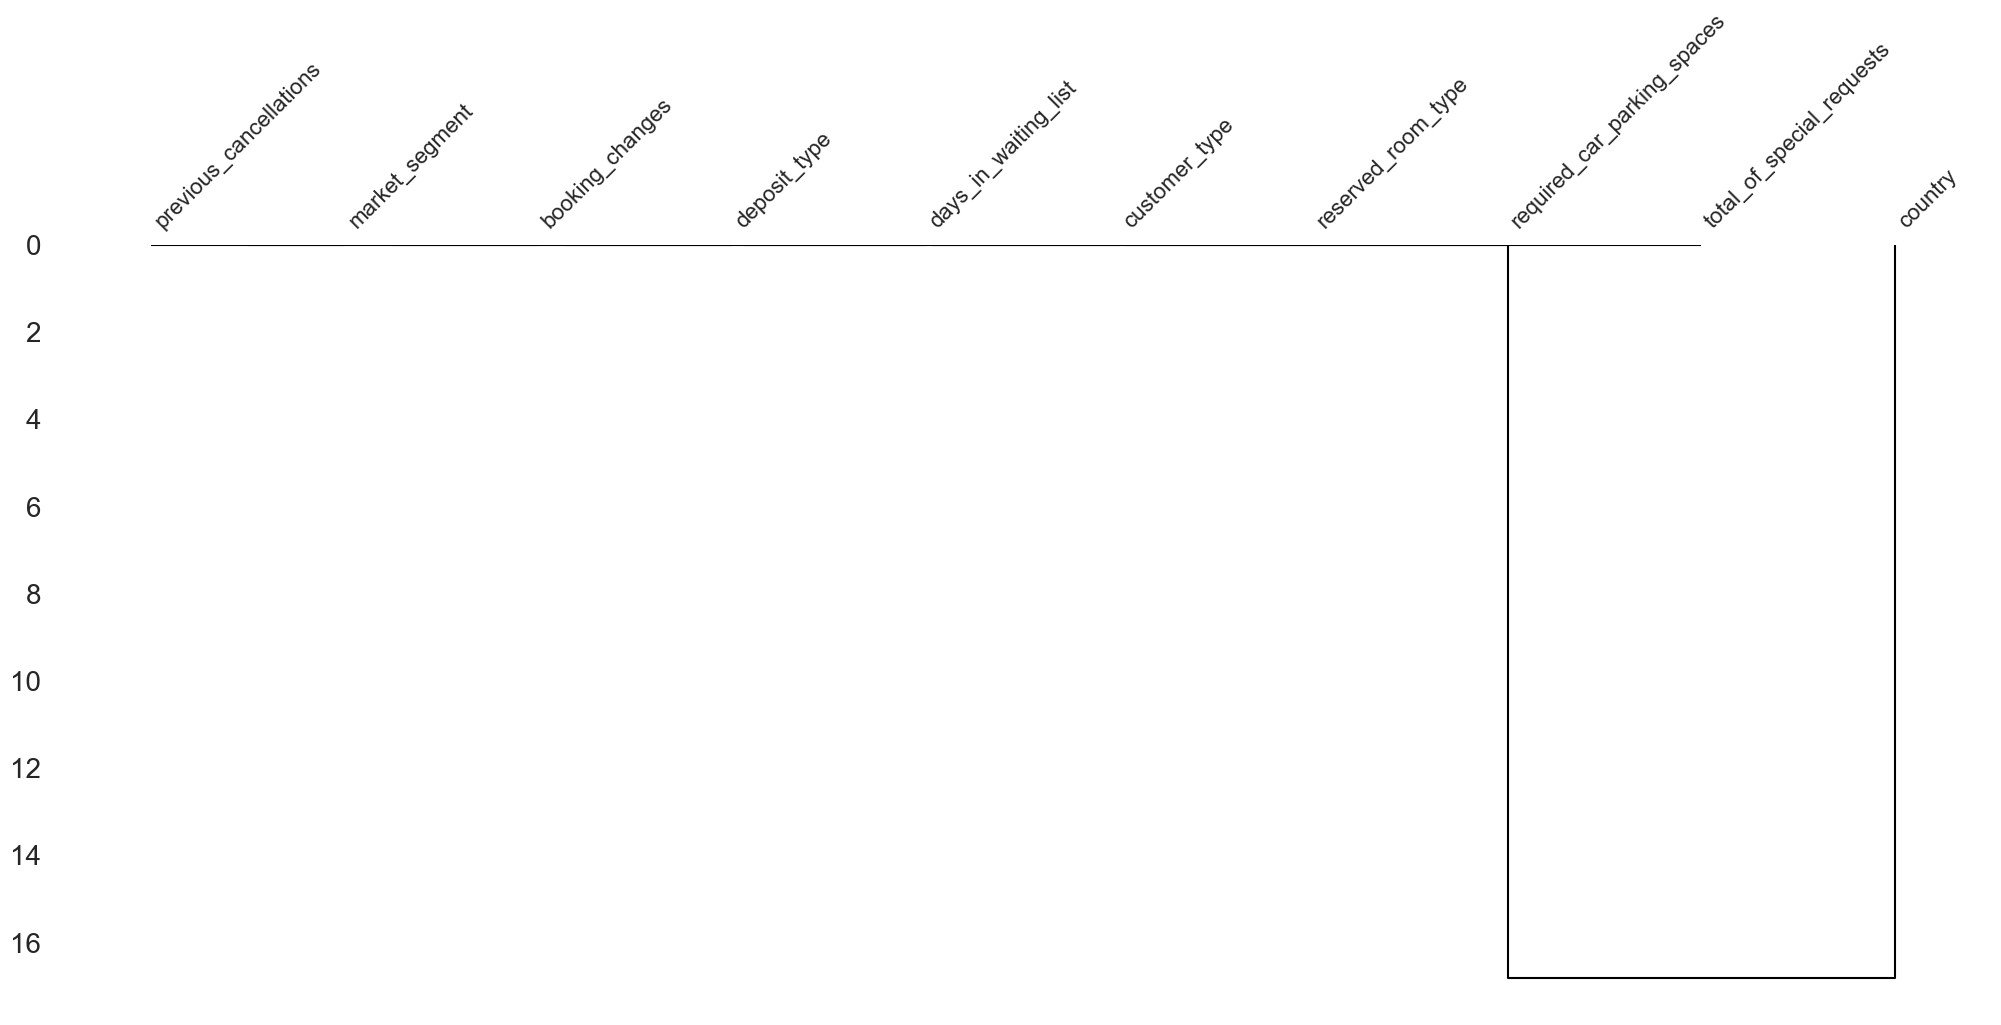

In [9]:
msno.dendrogram(x_train)
plt.show()

Terlihat pula bahwa `country` memiliki kesamaan pola null dengan `required_car_parking_spaces`. Hal ini menunjukkan kemungkinan bahwa adanya missing value pada `country` berhubungan dengan pola atau kondisi data dari `required_car_parking_spaces`, yang mana membuka peluang jika missing value bertipe MAR. Dan metode yang cocok digunakan antara: Impute mean/median/mode, atau Model-based Impute.

Namun, karena jumlah missing value yang sangat kecil, melakukan Model-based impute bisa jadi terlalu overkill. Sehingga, Impute berdasarkan mean/median/mode seharusnya sudah cukup.

Note: Karena country menjadi satu-satunya feature yang memiliki missing value, maka Heatmap bisa kita lewati karena country tidak punya pasangan untuk dibandingkan.

### Imputation

In [10]:
numeric_cols_raw = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
    
]

for col in numeric_cols_raw:
    if col in x_train.columns:
        x_train[col] = pd.to_numeric(x_train[col], errors='coerce')

categorical_cols = ['country', 'market_segment', 'deposit_type', 'customer_type', 'reserved_room_type']
numeric_feature_cols = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

print('Missing values sebelum Imputation:')
display(dataframe_profile(pd.concat([x_train, y_train], axis=1)).sort_values('missing', ascending=False))


# Imputation untuk data 
for col in categorical_cols:
    if col in x_train.columns and x_train[col].isna().any():
        x_train[col] = x_train[col].fillna(x_train[col].mode(dropna=True)[0])

for col in categorical_cols:
    if col in x_test.columns and x_test[col].isna().any():
        x_test[col] = x_test[col].fillna(x_train[col].mode(dropna=True)[0])

for col in numeric_feature_cols:
    if col in x_train.columns and x_train[col].isna().any():
        x_train[col] = x_train[col].fillna(x_train[col].median())

for col in numeric_feature_cols:
    if col in x_test.columns and x_test[col].isna().any():
        x_test[col] = x_test[col].fillna(x_train[col].median())

if y_train.isna().any():
    y_train = y_train.fillna(y_train.median())

if y_test.isna().any():
    y_test = y_test.fillna(y_train.median())

print('Missing values setelah Imputation:')
display(dataframe_profile(pd.concat([x_train, y_train], axis=1)).sort_values('missing', ascending=False))
print('Cancellation rate after cleaning: {:.2f}%'.format(df['is_canceled'].mean() * 100))
print()
print('Shape:', x_train.shape)
print()
x_train.info()

Missing values sebelum Imputation:


,feature,dtype,missing,missing_pct,n_unique,sample_values
0,country,string,283,0.42,156,"[PRT, BEL]"
1,market_segment,string,0,0.00,7,"[Offline TA/TO, Online TA]"
2,previous_cancellations,int64,0,0.00,15,"[0, 1]"
3,booking_changes,int64,0,0.00,19,"[0, 1]"
4,deposit_type,string,0,0.00,3,"[No Deposit, Non Refund]"
5,days_in_waiting_list,int64,0,0.00,112,"[0, 15]"
6,customer_type,string,0,0.00,4,"[Transient, Transient-Party]"
7,reserved_room_type,string,0,0.00,10,"[A, D]"
8,required_car_parking_spaces,int64,0,0.00,4,"[0, 1]"
9,total_of_special_requests,int64,0,0.00,6,"[0, 2]"


Missing values setelah Imputation:


,feature,dtype,missing,missing_pct,n_unique,sample_values
0,country,string,0,0.0,156,"[PRT, BEL]"
1,market_segment,string,0,0.0,7,"[Offline TA/TO, Online TA]"
2,previous_cancellations,int64,0,0.0,15,"[0, 1]"
3,booking_changes,int64,0,0.0,19,"[0, 1]"
4,deposit_type,string,0,0.0,3,"[No Deposit, Non Refund]"
5,days_in_waiting_list,int64,0,0.0,112,"[0, 15]"
6,customer_type,string,0,0.0,4,"[Transient, Transient-Party]"
7,reserved_room_type,string,0,0.0,10,"[A, D]"
8,required_car_parking_spaces,int64,0,0.0,4,"[0, 1]"
9,total_of_special_requests,int64,0,0.0,6,"[0, 2]"


Cancellation rate after cleaning: 36.83%

Shape: (66858, 10)

<class 'pandas.DataFrame'>
Index: 66858 entries, 52221 to 35304
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      66858 non-null  string
 1   market_segment               66858 non-null  string
 2   previous_cancellations       66858 non-null  int64 
 3   booking_changes              66858 non-null  int64 
 4   deposit_type                 66858 non-null  string
 5   days_in_waiting_list         66858 non-null  int64 
 6   customer_type                66858 non-null  string
 7   reserved_room_type           66858 non-null  string
 8   required_car_parking_spaces  66858 non-null  int64 
 9   total_of_special_requests    66858 non-null  int64 
dtypes: int64(5), string(5)
memory usage: 5.6 MB


### Ringkasan keputusan cleaning

- Missing value imputasi, bukan drop row.
- `drop_duplicate()` tidak dilakukan karena tidak ada unique identifier.

___

## Data Analysis / EDA


EDA di sini tidak hanya menampilkan plot, tetapi juga menjelaskan implikasinya pada keputusan modeling.

Karena target adalah cancel / tidak cancel, setiap visualisasi difokuskan pada hubungan fitur dengan `is_canceled`.

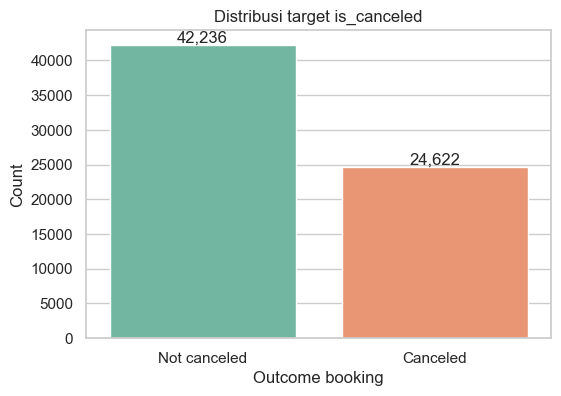

Cancellation rate: 36.83%


In [11]:
# Plot 1: distribusi target
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = y_train.value_counts().sort_index()
sns.barplot(x=['Not canceled', 'Canceled'], y=target_counts.values, palette='Set2', ax=ax)
ax.set_title('Distribusi target is_canceled')
ax.set_xlabel('Outcome booking')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + target_counts.max() * 0.01, f'{v:,}', ha='center')
plt.show()

print('Cancellation rate: {:.2f}%'.format(y_train.mean() * 100))

**Insight**

- Jika kelas tidak seimbang, accuracy bisa menipu karena model yang selalu menebak kelas mayoritas masih terlihat bagus.
- Karena itu recall, F1, dan PR AUC menjadi lebih penting daripada accuracy saja.
- Kelas cancel harus dipantau lebih serius karena false negative langsung mengurangi peluang mitigasi.

### Rare Categories Grouping

Rare Categories (kategori-kategori yang jumlahnya sangat sedikit) Grouping berguna pada dataset yang memiliki cardinality tinggi. Rare categories berpotensi membebani performa (redundancy) dan menyebabkan overfitting, karena rare categories membuat model tidak bisa mempelajari feature tersebut dengan baik akibat kurangnya data. Oleh karena itu, rare categories akan di-grouping ke dalam kategori baru sehingga dapat memperkecil jumlah kategori (juga dimensi) dan meningkatkan kualitas data dengan memperluas cakupan cluster.

Threshold yang digunakan bersifat subjektif, agar lebih aman mari kita set kategori dengan jumlah count <50 sebagai rare categories agar nantinya tidak mempengaruhi data baru dengan kategori tersebut. Threshold 50 dipilih karena data dengan jumlah ≥50 titik relatif cukup untuk merepresentasikan nilai persentase/rate dari target `is_canceled`.


**1. Kolom `deposit_type`**

In [12]:
print(pd.concat([x_train, y_train], axis=1).groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))

                  mean  count
deposit_type                 
Refundable    0.172840     81
Non Refund    0.993557   8071
No Deposit    0.282578  58706


Kesimpulan: OK.

**2. Kolom `market_segment`**

In [13]:
print(pd.concat([x_train, y_train], axis=1).groupby('market_segment')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))

                    mean  count
market_segment                 
Aviation        0.201550    129
Complementary   0.141772    395
Corporate       0.180583   3018
Direct          0.152725   7065
Groups          0.613412  10960
Offline TA/TO   0.340218  13606
Online TA       0.364968  31685


Kesimpulan: OK (biarkan sebagai `Undefined`)

**3. Kolom `customer_type`**

In [14]:
print(pd.concat([x_train, y_train], axis=1).groupby('customer_type')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))

                     mean  count
customer_type                   
Group            0.097633    338
Contract         0.304108   2361
Transient-Party  0.256819  14115
Transient        0.404564  50044


Kesimpulan: OK.

**4. Kolom `reserved_room_type`**

In [15]:
print(pd.concat([x_train, y_train], axis=1).groupby('reserved_room_type')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))

                        mean  count
reserved_room_type                 
L                   0.500000      2
P                   1.000000      5
H                   0.420896    335
C                   0.314394    528
B                   0.319218    614
G                   0.362369   1148
F                   0.308498   1624
E                   0.285328   3701
D                   0.316050  10897
A                   0.389468  48004


In [16]:
top_rooms = x_train['reserved_room_type'].value_counts().loc[lambda x: x >= 50].index

x_train['reserved_room_type'] = x_train['reserved_room_type'].where(x_train['reserved_room_type'].isin(top_rooms), 'Others')
x_test['reserved_room_type'] = x_test['reserved_room_type'].where(x_test['reserved_room_type'].isin(top_rooms), 'Others')

print('Train Data')
print(pd.concat([x_train, y_train], axis=1).groupby('reserved_room_type')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))
print()
print('Test Data')
print(pd.concat([x_test, y_test], axis=1).groupby('reserved_room_type')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))


Train Data
                        mean  count
reserved_room_type                 
Others              0.857143      7
H                   0.420896    335
C                   0.314394    528
B                   0.319218    614
G                   0.362369   1148
F                   0.308498   1624
E                   0.285328   3701
D                   0.316050  10897
A                   0.389468  48004

Test Data
                        mean  count
reserved_room_type                 
Others              0.800000      5
H                   0.333333     66
C                   0.324138    145
B                   0.341040    173
G                   0.344482    299
F                   0.254237    413
E                   0.311181    948
D                   0.313808   2629
A                   0.390130  12037


Kesimpulan: Kamar tipe L & tipe P memiliki jumlah booking <50. Set sebagai `Others`.

**5. Kolom `country`**

Sanity check terlebih dahulu.

In [17]:
x_train['country'].unique().tolist()

['PRT',
 'BEL',
 'FIN',
 'ARE',
 'FRA',
 'DEU',
 'AGO',
 'ESP',
 'CN',
 'SWE',
 'GBR',
 'BRA',
 'PRI',
 'VEN',
 'USA',
 'ARG',
 'IRL',
 'NOR',
 'CYP',
 'IND',
 'CHE',
 'NGA',
 'MAR',
 'HKG',
 'TUR',
 'AUS',
 'ITA',
 'LBN',
 'NLD',
 'POL',
 'ECU',
 'CHN',
 'ROU',
 'THA',
 'AUT',
 'ISR',
 'VNM',
 'CZE',
 'EST',
 'BGR',
 'ISL',
 'ZAF',
 'DNK',
 'GRC',
 'SVN',
 'RUS',
 'UKR',
 'LUX',
 'IDN',
 'CUB',
 'URY',
 'COL',
 'LVA',
 'PHL',
 'JPN',
 'DZA',
 'SGP',
 'HUN',
 'DMA',
 'SAU',
 'IRN',
 'HRV',
 'PER',
 'CHL',
 'PAK',
 'JOR',
 'MEX',
 'TUN',
 'BEN',
 'MOZ',
 'BLR',
 'AZE',
 'CRI',
 'KOR',
 'TMP',
 'LTU',
 'ETH',
 'EGY',
 'NZL',
 'UZB',
 'GNB',
 'SVK',
 'MLT',
 'SRB',
 'MAC',
 'MKD',
 'BDI',
 'TWN',
 'KAZ',
 'ALB',
 'LBY',
 'KNA',
 'OMN',
 'LIE',
 'CPV',
 'MDV',
 'CIV',
 'GIB',
 'MYS',
 'ABW',
 'MUS',
 'BIH',
 'GGY',
 'SEN',
 'KHM',
 'AND',
 'BHR',
 'KWT',
 'SUR',
 'QAT',
 'GHA',
 'PRY',
 'ARM',
 'IRQ',
 'FRO',
 'DOM',
 'PAN',
 'GEO',
 'UGA',
 'LKA',
 'SYR',
 'MMR',
 'CAF',
 'ZMB',
 'BOL',
 

Terlihat China memiliki 2 Country Code, yakni 'CHN' dan 'CN', perlu disamakan terlebih dahulu.

In [18]:
x_train['country'] = x_train['country'].replace('CN', 'CHN')
x_test['country'] = x_test['country'].replace('CN', 'CHN')

pd.set_option('display.max_rows', None)
print(pd.concat([x_train, y_train], axis=1).groupby('country')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))
pd.reset_option('display.max_rows')

             mean  count
country                 
AIA      0.000000      1
BFA      0.000000      1
BEN      1.000000      1
BDI      0.000000      1
BWA      0.000000      1
GLP      1.000000      1
DMA      0.000000      1
CYM      0.000000      1
MLI      0.000000      1
MMR      0.000000      1
MYT      1.000000      1
LAO      0.000000      1
KIR      0.000000      1
KNA      0.000000      1
LCA      0.000000      1
IMN      1.000000      1
RWA      0.000000      1
PLW      0.000000      1
ZMB      1.000000      1
VGB      1.000000      1
UGA      0.000000      1
SYR      0.000000      1
SYC      1.000000      1
SUR      0.000000      1
UMI      1.000000      1
CAF      0.000000      2
LKA      0.000000      2
KHM      1.000000      2
MWI      0.000000      2
PRY      0.000000      2
JAM      0.000000      2
LIE      0.000000      2
MNE      0.500000      2
COM      0.000000      2
GTM      0.000000      2
GGY      1.000000      2
ETH      0.500000      2
ABW      0.000000      2


Kesimpulan: Negara dengan jumlah booking <50 sangat banyak. Set sebagai `Others`.

In [19]:
top_countries = x_train['country'].value_counts().loc[lambda x: x >= 50].index

x_train['country'] = x_train['country'].where(x_train['country'].isin(top_countries), 'Others')
x_test['country'] = x_test['country'].where(x_test['country'].isin(top_countries), 'Others')

pd.set_option('display.max_rows', None)

print('Train Data')
print(pd.concat([x_train, y_train], axis=1).groupby('country')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))
print()
print('Test Data')
print(pd.concat([x_test, y_test], axis=1).groupby('country')['is_canceled'].agg(['mean', 'count']).sort_values(by='count'))
pd.reset_option('display.max_rows')

Train Data
             mean  count
country                 
HRV      0.267857     56
DZA      0.225806     62
GRC      0.313433     67
SRB      0.029412     68
KOR      0.425000     80
IND      0.175000     80
CZE      0.175258     97
JPN      0.114286    105
HUN      0.315789    114
TUR      0.412698    126
ARG      0.242424    132
MAR      0.433566    143
LUX      0.340278    144
AGO      0.578947    190
DNK      0.260331    242
AUS      0.254098    244
FIN      0.158537    246
ROU      0.271062    273
RUS      0.377581    339
NOR      0.293948    347
ISR      0.257294    377
POL      0.215649    524
SWE      0.219684    569
AUT      0.175887    705
CHE      0.228571    980
NLD      0.170139   1152
USA      0.235046   1187
BRA      0.391408   1257
CHN      0.304112   1289
Others   0.339651   1319
BEL      0.194717   1325
IRL      0.240899   1868
ITA      0.348632   2157
DEU      0.166139   4105
ESP      0.255191   4816
FRA      0.185856   5854
GBR      0.203450   6783
PRT      0.559

### **Visualize Data**

#### 1. Categorical Features

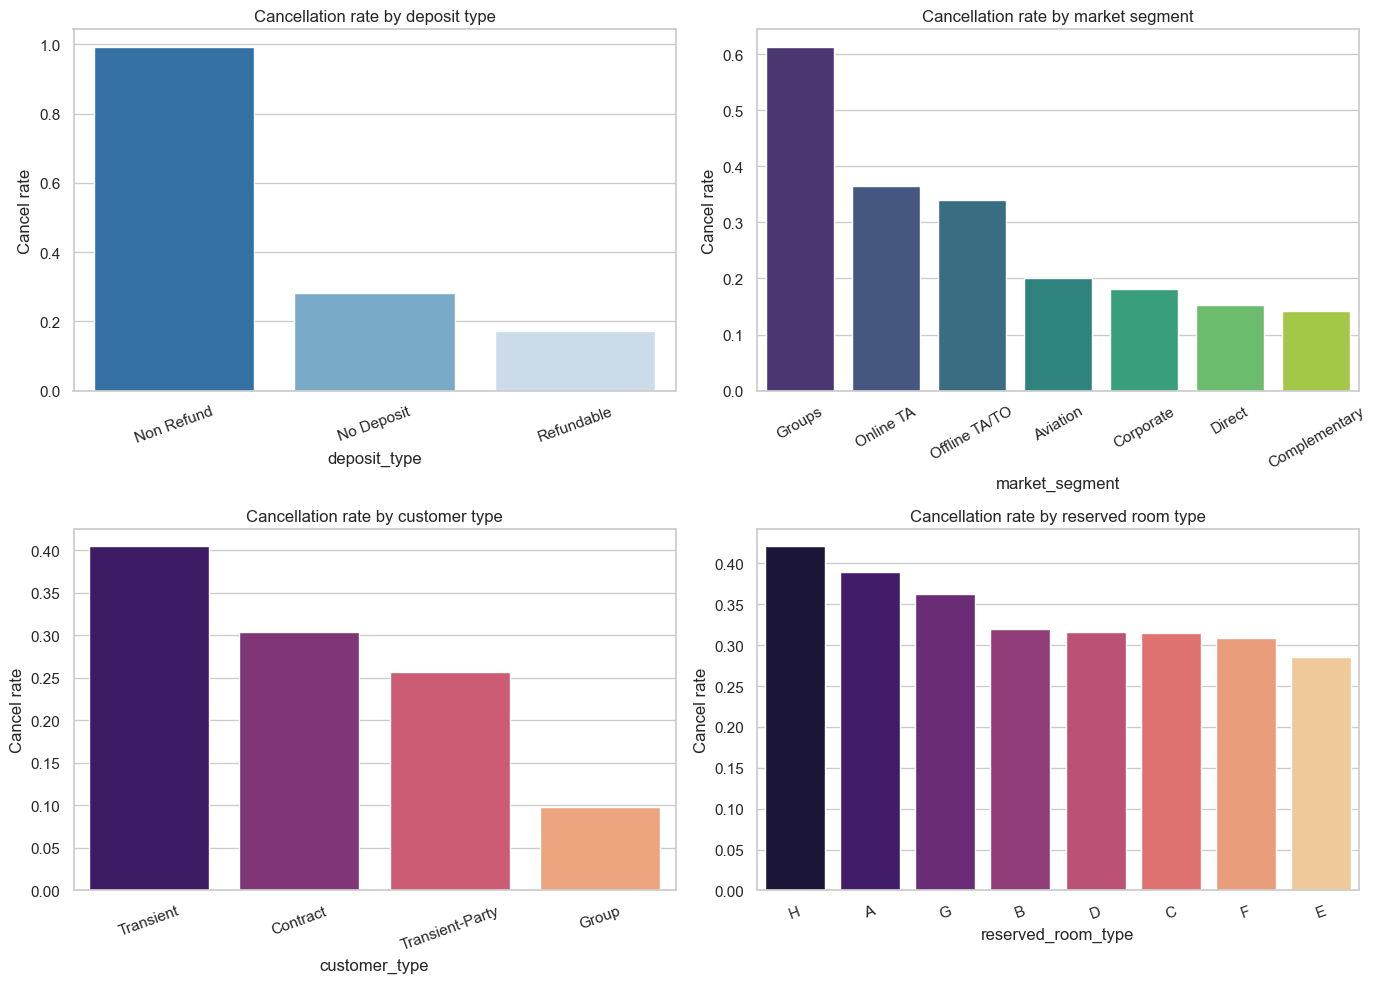

,deposit_type,mean,count
0,Non Refund,0.993557,8071
1,No Deposit,0.282578,58706
2,Refundable,0.172840,81


,market_segment,is_canceled
0,Groups,0.613412
1,Online TA,0.364968
2,Offline TA/TO,0.340218
3,Aviation,0.201550
4,Corporate,0.180583
5,Direct,0.152725
6,Complementary,0.141772


,customer_type,is_canceled
0,Transient,0.404564
1,Contract,0.304108
2,Transient-Party,0.256819
3,Group,0.097633


,reserved_room_type,is_canceled
0,H,0.420896
1,A,0.389468
2,G,0.362369
3,B,0.319218
4,D,0.316050
5,C,0.314394
6,F,0.308498
7,E,0.285328


In [20]:
train_combined = pd.concat([x_train, y_train], axis=1)

# Plot 2: cancellation rate by deposit type and customer / market segment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

deposit_rate = train_combined.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False).reset_index()
sns.barplot(data=deposit_rate, x='deposit_type', y='mean', palette='Blues_r', ax=axes[0,0])
axes[0,0].set_title('Cancellation rate by deposit type')
axes[0,0].set_xlabel('deposit_type')
axes[0,0].set_ylabel('Cancel rate')
axes[0,0].tick_params(axis='x', rotation=20)

market_rate = train_combined[train_combined['market_segment']!='Undefined'].groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=market_rate, x='market_segment', y='is_canceled', palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Cancellation rate by market segment')
axes[0,1].set_xlabel('market_segment')
axes[0,1].set_ylabel('Cancel rate')
axes[0,1].tick_params(axis='x', rotation=30)

customer_rate = train_combined.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=customer_rate, x='customer_type', y='is_canceled', palette='magma', ax=axes[1,0])
axes[1,0].set_title('Cancellation rate by customer type')
axes[1,0].set_xlabel('customer_type')
axes[1,0].set_ylabel('Cancel rate')
axes[1,0].tick_params(axis='x', rotation=20)

reserved_room_rate = train_combined[train_combined['reserved_room_type']!='Others'].groupby('reserved_room_type')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=reserved_room_rate, x='reserved_room_type', y='is_canceled', palette='magma', ax=axes[1,1])
axes[1,1].set_title('Cancellation rate by reserved room type')
axes[1,1].set_xlabel('reserved_room_type')
axes[1,1].set_ylabel('Cancel rate')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

display(deposit_rate)
display(market_rate)
display(customer_rate)
display(reserved_room_rate)

**Insight**

- `deposit_type` biasanya sangat relevan untuk perilaku cancel karena deposit meningkatkan komitmen pelanggan.
- `market_segment` dan `customer_type` menunjukkan adanya perbedaan perilaku antar channel dan tipe booking.
- `reserved_room_type` menunjukkan perbedaan tipe kamar memiliki pengaruh kepada kemungkinan pembatalan walaupun tidak besar.
- Fitur-fitur ini harus dipertahankan dan di-encode secara kategorikal dengan One-Hot Encoder, menjadikannya ordinal berpotensi memberikan informasi yang salah pada model.
- Ini juga menjadi sinyal bahwa model tree-based kemungkinan akan menangkap interaksi antar kategori dengan baik.

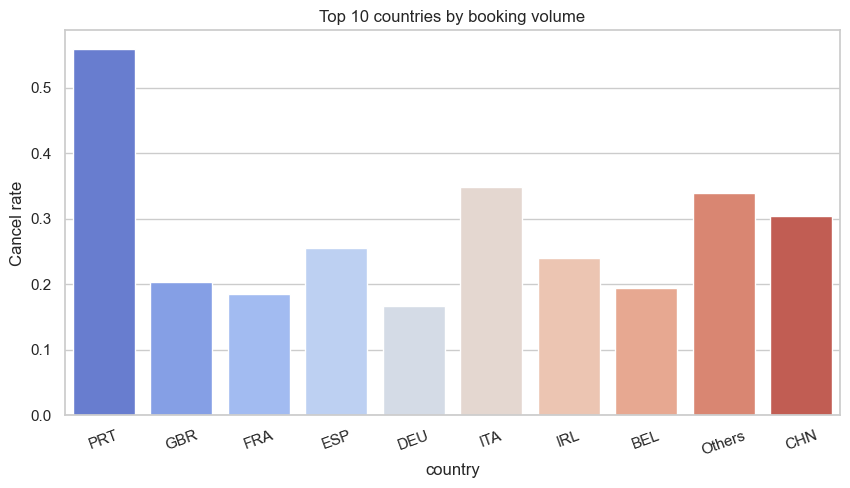

,country,mean,count
0,PRT,0.559666,27436
1,GBR,0.203450,6783
2,FRA,0.185856,5854
3,ESP,0.255191,4816
4,DEU,0.166139,4105
5,ITA,0.348632,2157
6,IRL,0.240899,1868
7,BEL,0.194717,1325
8,Others,0.339651,1319
9,CHN,0.304112,1289


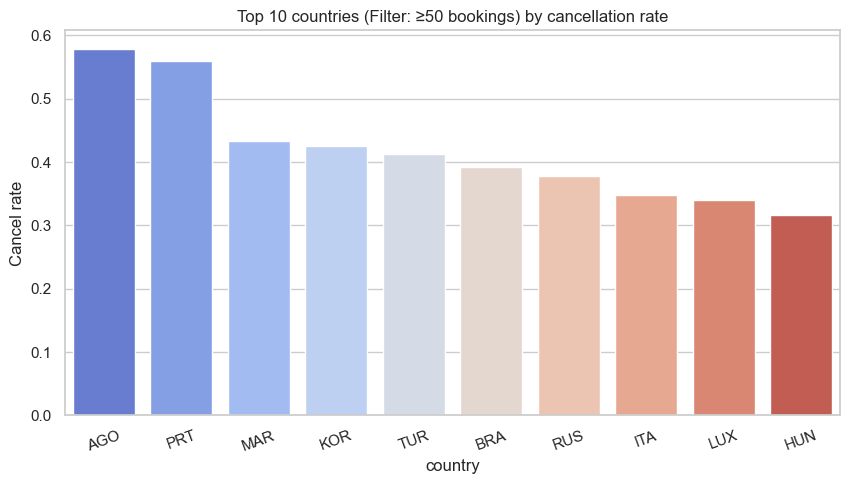

,country,cancel_rate,count
0,AGO,0.578947,190
1,PRT,0.559666,27436
2,MAR,0.433566,143
3,KOR,0.425000,80
4,TUR,0.412698,126
5,BRA,0.391408,1257
6,RUS,0.377581,339
7,ITA,0.348632,2157
8,LUX,0.340278,144
9,HUN,0.315789,114


In [21]:
# Plot 3: top countries with cancellation rate
top_countries = train_combined['country'].value_counts().head(10).index
country_rate = (
    train_combined[train_combined['country'].isin(top_countries)]
    .groupby('country')['is_canceled']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .reset_index()
)

country_cancel = (
    train_combined[train_combined['country'] != 'Others'].groupby('country')['is_canceled']
    .agg(['mean', 'count'])
    .reset_index()
)
country_cancel.columns = ['country', 'cancel_rate', 'count']
country_cancel = country_cancel.sort_values(by='cancel_rate', ascending=False).reset_index(drop=True)

fig = px.choropleth(
    country_cancel,
    locations="country",
    color="cancel_rate",
    color_continuous_scale="Reds",
    title="Cancellation Rate by Country (Filter: ≥50 bookings)",
    hover_data={
        "cancel_rate": ':.2f', 
        "count": True
    }
)

fig.show()


fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=country_rate, x='country', y='mean', palette='coolwarm', ax=ax)
ax.set_title('Top 10 countries by booking volume')
ax.set_xlabel('country')
ax.set_ylabel('Cancel rate')
ax.tick_params(axis='x', rotation=20)
plt.show()

display(country_rate)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=country_cancel.head(10), x='country', y='cancel_rate', palette='coolwarm', ax=ax)
ax.set_title('Top 10 countries (Filter: ≥50 bookings) by cancellation rate')
ax.set_xlabel('country')
ax.set_ylabel('Cancel rate')
ax.tick_params(axis='x', rotation=20)
plt.show()

display(country_cancel.head(10))

**Insight**

- `country` memiliki banyak kategori, jadi harus diperlakukan sebagai fitur nominal, bukan ordinal.
- Rare categories grouping sudah diterapkan pada feature `country` untuk memperkecil cardinality.
- Mempertahankan `country` berpotensi menciptakan diskriminasi kebijakan terhadap tamu dari wilayah atau etnis tertentu, terutama jika berkumpul dalam satu cluster. Namun, mengecualikan `country` ke dalam training juga berpotensi menghilangkan informasi-informasi yang mungkin saja relevan terhadap kemungkinan cancel.
- Dalam kasus ini, negara-negara dengan cancellation rate paling tinggi tidak terlihat memiliki pola atau kesamaan khusus, sehingga sulit untuk di-grouping. Persebarannya juga acak, sehingga kecil kemungkinan terjadinya diskriminasi etnis.
- Top-country analysis membantu melihat apakah ada negara tertentu yang lebih berisiko cancel. Terlihat jelas bahwa tamu dari Portugal (domestik) di antara yang paling memiliki kemungkinan melakukan cancel. Oleh karena itu, feature ini terbukti memiliki pengaruh terhadap kemungkinan cancel dan tetap dibiarkan apa adanya.
- Karena cardinality cukup tinggi, one-hot encoding dengan `handle_unknown='ignore'` adalah pilihan paling aman untuk notebook ini.

#### 2. Numerical Features

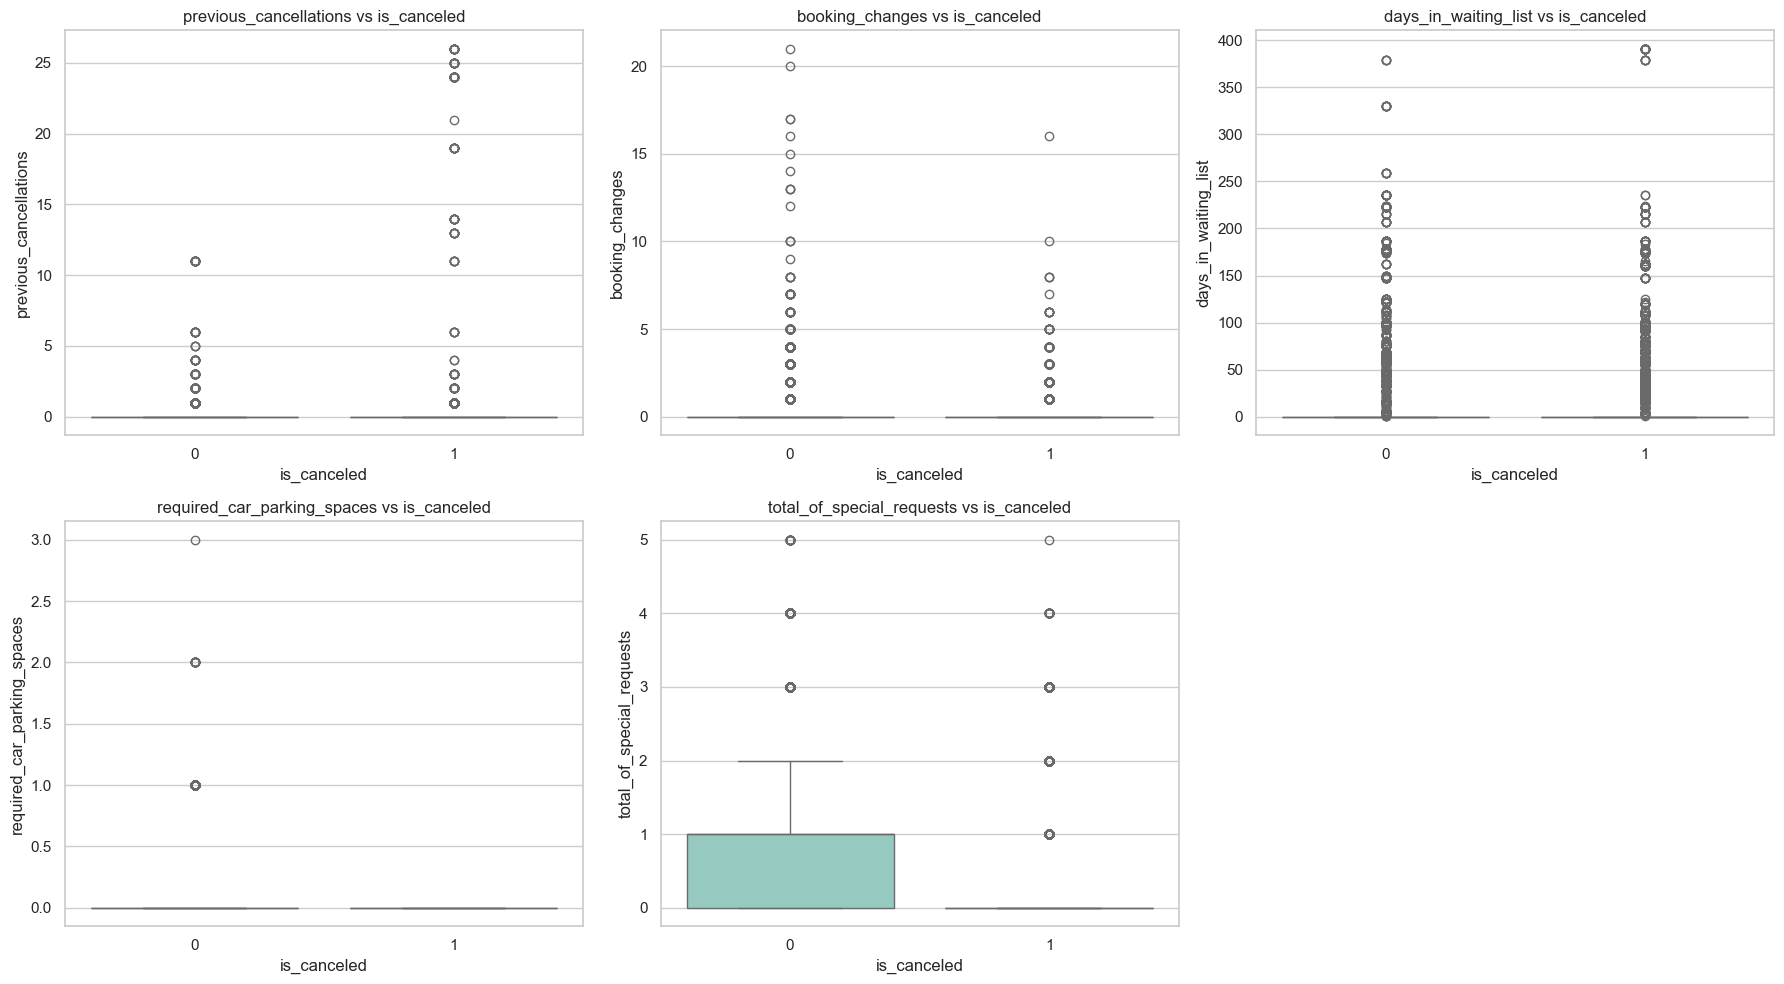

,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
is_canceled,,,,,
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0


In [22]:
# Plot 4: numeric features vs target
num_plot_cols = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_plot_cols):
    sns.boxplot(data=train_combined, x='is_canceled', y=col, ax=axes[i], palette='Set3')
    axes[i].set_title(f'{col} vs is_canceled')
    axes[i].set_xlabel('is_canceled')
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

display(train_combined.groupby('is_canceled')[num_plot_cols].median())

**Insight**

- Fitur numerik di sini adalah count-based dan cenderung zero-heavy, sehingga boxplot lebih informatif daripada asumsi distribusi normal.
- Jika median atau ekor distribusi berbeda antara kelas cancel dan non-cancel, model tree akan mudah menangkap threshold tersebut.
- Untuk membantu Logistic Regression, kita akan menambahkan fitur biner sederhana seperti `has_special_requests` atau `has_booking_changes`.
- Tamu dengan `total_of_special_requests` cenderung lebih berpotensi untuk tidak melakukan cancel dibanding yang tidak. Ada kemungkinan special request justru menunjukkan excitement tamu dan meningkatkan komitmen tamu untuk tetap datang.

___

## Feature Engineering

Ada beberapa metode yang bisa dilakukan dalam Feature Engineering:

1. **Feature Creation**
   Membuat feature baru berdasarkan domain knowledge atau observasi pola pada data, seperti:
   - Domain-specific: Berdasarkan industry knowledge seperti business rule.
   - Data-driven: Berdasarkan pola pada data.
   - Synthetic: Dengan menggabungkan feature-feature yang ada pada dataset.

2. **Feature Transformation**
   Transformasi feature-feature yang sudah ada, seperti:
   - Normalization & Scaling: Menyetarakan skala feature-feature untuk konsistensi.
   - Encoding: Konversi data kategorikal ke bentuk numerical (contoh: one-hot encoding).
   - Mathematical Transformation: Menggunakan rumus-rumus matematika (contoh: transformasi logaritmik)

3. **Feature Extraction**
   Ekstraksi informasi-informasi yang bermanfaat dari data untuk mengurangi dimensionality dan meningkatkan akurasi model, seperti:
   - Dimensionality reduction (contoh: PCA).
   - Aggregation & Combination: Melakukan penjumlahan atau rata-rata dari feature untuk menyederhanakan model.

4. **Feature Selection**
   Memilah subset dari feature-feature yang relevan, seperti:
   - Filter Methods: Berdasarkan pengukuran statistika seperti correlation.
   - Wrapper Methods: Berdasarkan performa model.
   - Embedded Methods: Feature Selection ntegrated di dalam model training.

5. **Feature Scaling**
   Memastikan semua feature berkontribusi secara seimbang pada model, seperti:
   - Min-max Scaling: Menyesuaikan nilai-nilai ke rentang tetap, misalnya 0 hingga 1.
   - Standard Scaling: Menormalkan data sehingga memiliki rata-rata 0 dan varians 1.

Reference:
- https://www.geeksforgeeks.org/machine-learning/what-is-feature-engineering/

### Pertimbangan dan Keputusan
Dengan dataset yang kita miliki, tidak semua metode dalam Feature Engineering bisa atau perlu dilakukan.
Dari hasil EDA yang telah dilakukan, berikut metode Feature Engineering yang akan dikerjakan sebelum model training:

Mempertahankan feature asli:
| Feature | Data Type | Encoder |
| - | - | - |
| `country` | Nominal | One-Hot Encoder |
| `market_segment` | Nominal | One-Hot Encoder |
| `customer_type` | Nominal | One-Hot Encoder |
| `deposit_type` | Nominal | One-Hot Encoder |
| `previous_cancellations` | Numerical | Scaling |
| `booking_changes` | Numerical | Scaling |
| `days_in_waiting_list` | Numerical | Scaling |
| `required_car_parking_spaces` | Numerical | Scaling |
| `total_of_special_requests` | Numerical | Scaling |
| `is_canceled` | Binary | Target Encoder |

Menambah beberapa feature baru:
| Feature | Data Type |
| - | - |
| `has_previous_cancellations` | Binary |
| `has_booking_changes` | Binary |
| `is_waiting_list` | Binary |
| `needs_parking` | Binary |
| `has_special_requests` | Binary |


### Encoding strategy
- Fitur kategorikal nominal: **One-Hot Encoding**.
- **Label encoding ditolak** karena akan menciptakan false ordinal.
- Fitur numerik: tetap numerik, dan untuk Logistic Regression akan distandarisasi.

Strategi ini cocok untuk data campuran numerik dan kategorikal seperti pada problem cancel booking.

In [23]:
# Feature Engineering

target_col = 'is_canceled'

categorical_features = [
    'country',
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]

# Base numeric (used by ALL models)
base_numeric_features = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# Engineered features (ONLY for Logistic Regression)
engineered_features = [
    'has_previous_cancellations',
    'has_booking_changes',
    'is_waiting_list',
    'needs_parking',
    'has_special_requests'
]

# Final feature sets
lr_numeric_features = base_numeric_features + engineered_features
tree_numeric_features = base_numeric_features

class FeatureEngineerLR(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X['has_previous_cancellations'] = (X['previous_cancellations'] > 0).astype(int)
        X['has_booking_changes'] = (X['booking_changes'] > 0).astype(int)
        X['is_waiting_list'] = (X['days_in_waiting_list'] > 0).astype(int)
        X['needs_parking'] = (X['required_car_parking_spaces'] > 0).astype(int)
        X['has_special_requests'] = (X['total_of_special_requests'] > 0).astype(int)
        
        return X

numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lr, lr_numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_tree, tree_numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

def get_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob)
    }

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = get_metrics(y_test, y_pred, y_prob)
    
    print(f'\n{name}')
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    
    return metrics, y_pred, y_prob

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def random_undersample(X_input, y_input, random_state=42):
    temp = X_input.copy()
    temp['target'] = y_input.values
    
    majority = temp[temp['target'] == 0]
    minority = temp[temp['target'] == 1]
    
    majority_downsampled = majority.sample(
        n=len(minority),
        random_state=random_state
    )
    
    balanced = pd.concat([majority_downsampled, minority], axis=0)\
        .sample(frac=1, random_state=random_state)
    
    return balanced.drop(columns=['target']), balanced['target']

## Handling Class Imbalance

### Yang dibandingkan
1. **Class weight**
   - Semua data tetap dipakai.
   - Penalti untuk kelas minoritas diperbesar.
   - Cocok ketika kita tidak ingin kehilangan informasi.

2. **Random undersampling**
   - Kelas mayoritas dipotong agar seimbang.
   - Lebih cepat, tetapi membuang informasi.

In [24]:
print('Distribusi target pada train set:')
display(y_train.value_counts().rename(index={0: 'not_canceled', 1: 'canceled'}))
print('Cancellation rate train: {:.2f}%'.format(y_train.mean() * 100))

x_train_us, y_train_us = random_undersample(x_train, y_train, random_state=42)

lr_balanced = Pipeline(steps=[
    ('feature_engineering', FeatureEngineerLR()),
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_undersampled = Pipeline(steps=[
    ('feature_engineering', FeatureEngineerLR()),
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_balanced.fit(x_train, y_train)
lr_undersampled.fit(x_train_us, y_train_us)

m_bal, pred_bal, prob_bal = evaluate_model('Logistic Regression - class_weight=balanced', lr_balanced, x_test, y_test)
m_us, pred_us, prob_us = evaluate_model('Logistic Regression - random undersampling', lr_undersampled, x_test, y_test)

imbalance_compare = pd.DataFrame([
    {'approach': 'class_weight=balanced', **m_bal},
    {'approach': 'random_undersampling', **m_us}
]).sort_values(['recall', 'f1', 'pr_auc'], ascending=False)

display(imbalance_compare)

Distribusi target pada train set:


is_canceled
not_canceled    42236
canceled        24622
Name: count, dtype: int64

Cancellation rate train: 36.83%

Logistic Regression - class_weight=balanced
              precision    recall  f1-score   support

           0     0.8177    0.8506    0.8339     10559
           1     0.7248    0.6748    0.6989      6156

    accuracy                         0.7859     16715
   macro avg     0.7713    0.7627    0.7664     16715
weighted avg     0.7835    0.7859    0.7842     16715


Logistic Regression - random undersampling
              precision    recall  f1-score   support

           0     0.8452    0.7903    0.8169     10559
           1     0.6764    0.7518    0.7121      6156

    accuracy                         0.7761     16715
   macro avg     0.7608    0.7711    0.7645     16715
weighted avg     0.7831    0.7761    0.7783     16715



,approach,accuracy,precision,recall,f1,roc_auc,pr_auc
1,random_undersampling,0.776129,0.67641,0.751787,0.712110,0.868980,0.822943
0,class_weight=balanced,0.785881,0.72483,0.674789,0.698915,0.869246,0.823317


### Kesimpulan imbalance handling

Bila tujuan utama adalah menangkap booking cancel sebanyak mungkin tanpa kehilangan terlalu banyak presisi, terlihat bahwa undersampling memberikan score Recall dan F1 yang lebih tinggi dibanding Class Weight.

## Modeling

Kita bandingkan tiga model yang mewakili trade-off yang berbeda:

1. **Logistic Regression**
   - Kelebihan: baseline yang interpretabel dan cepat.
   - Kelemahan: pola hubungan dianggap lebih linear setelah encoding.

2. **Decision Tree**
   - Kelebihan: mudah dijelaskan sebagai rule-based model.
   - Kelemahan: mudah overfit dan sensitif terhadap perubahan data.

3. **Random Forest**
   - Kelebihan: biasanya lebih kuat karena menggabungkan banyak tree dan menangkap interaksi non-linear.
   - Kelemahan: lebih sulit diinterpretasikan daripada satu tree.

Untuk data booking hotel yang memiliki kombinasi fitur kategorikal, fitur count yang skewed, dan interaksi kompleks, Random Forest sangat masuk akal sebagai kandidat terbaik.

In [25]:
baseline_models = {
    'Logistic Regression': Pipeline(steps=[
        ('feature_engineering', FeatureEngineerLR()),
        ('preprocess', preprocess_lr),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocess', preprocess_tree),
        ('model', DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            min_samples_leaf=20
        ))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocess', preprocess_tree),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

baseline_results = []
baseline_predictions = {}
baseline_probabilities = {}

for name, model in baseline_models.items():
    model.fit(x_train_us, y_train_us)
    
    metrics, y_pred, y_prob = evaluate_model(name, model, x_test, y_test)
    
    baseline_results.append({'model': name, **metrics})
    baseline_predictions[name] = y_pred
    baseline_probabilities[name] = y_prob

baseline_df = pd.DataFrame(baseline_results)\
    .sort_values(['recall', 'f1', 'pr_auc'], ascending=False)

display(baseline_df)


Logistic Regression
              precision    recall  f1-score   support

           0     0.8452    0.7903    0.8169     10559
           1     0.6764    0.7518    0.7121      6156

    accuracy                         0.7761     16715
   macro avg     0.7608    0.7711    0.7645     16715
weighted avg     0.7831    0.7761    0.7783     16715


Decision Tree
              precision    recall  f1-score   support

           0     0.8503    0.7739    0.8103     10559
           1     0.6640    0.7662    0.7115      6156

    accuracy                         0.7711     16715
   macro avg     0.7571    0.7701    0.7609     16715
weighted avg     0.7817    0.7711    0.7739     16715


Random Forest
              precision    recall  f1-score   support

           0     0.8713    0.7806    0.8235     10559
           1     0.6807    0.8023    0.7365      6156

    accuracy                         0.7886     16715
   macro avg     0.7760    0.7914    0.7800     16715
weighted avg     0.8011

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Random Forest,0.788573,0.680678,0.802307,0.736505,0.889496,0.846025
1,Decision Tree,0.771104,0.663992,0.766244,0.711463,0.867080,0.795832
0,Logistic Regression,0.776129,0.676410,0.751787,0.712110,0.868980,0.822943


Dari output tersebut, terlihat bahwa Random Forest memiliki performa yang paling unggul dalam mendeteksi potensi cancel secara keseluruhan.

### Evaluasi dan interpretasi

- **Accuracy** penting sebagai gambaran umum, tetapi bukan penentu utama.
- **Precision** menunjukkan seberapa efisien intervensi hotel terhadap booking yang diprediksi cancel.
- **Recall** adalah metrik utama karena hotel tidak ingin melewatkan booking cancel yang sebenarnya.
- **F1-score** berguna untuk melihat keseimbangan precision dan recall.
- **ROC AUC** menilai kualitas ranking secara keseluruhan.
- **PR AUC** lebih relevan bila kelas positif lebih sulit dideteksi.

Jika ada model dengan accuracy tinggi tetapi recall rendah pada kelas cancel, maka model tersebut tidak cocok untuk kebutuhan bisnis.

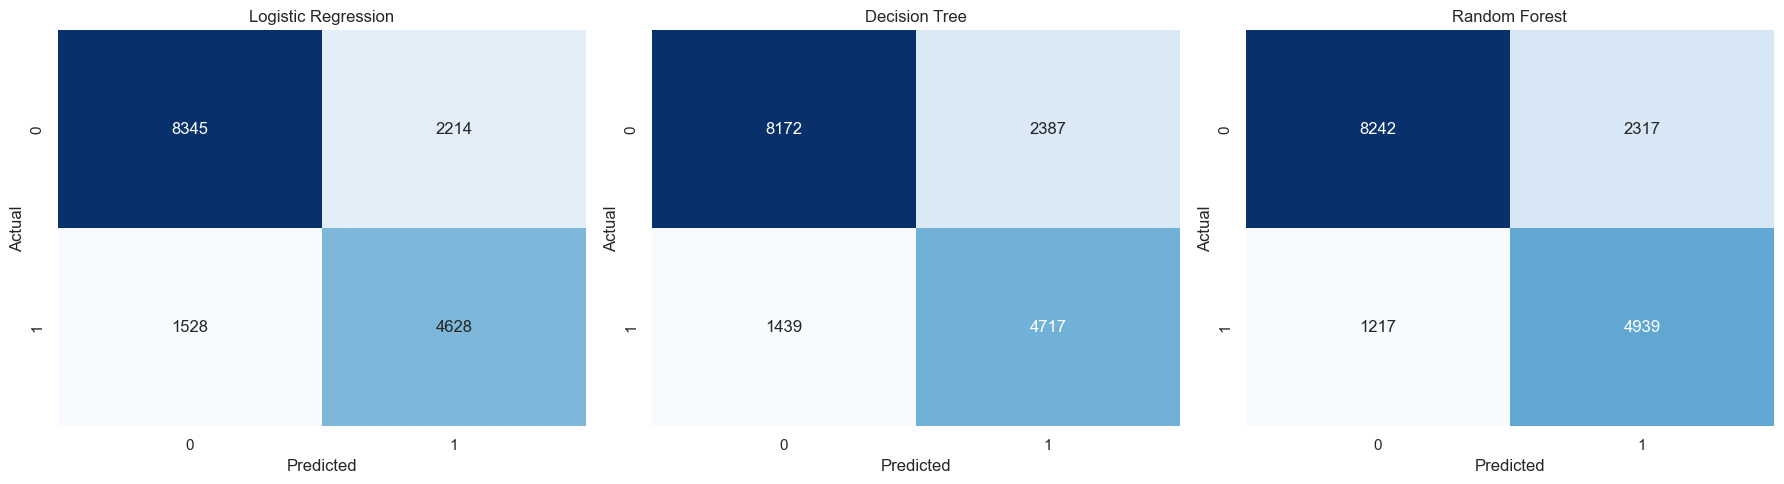

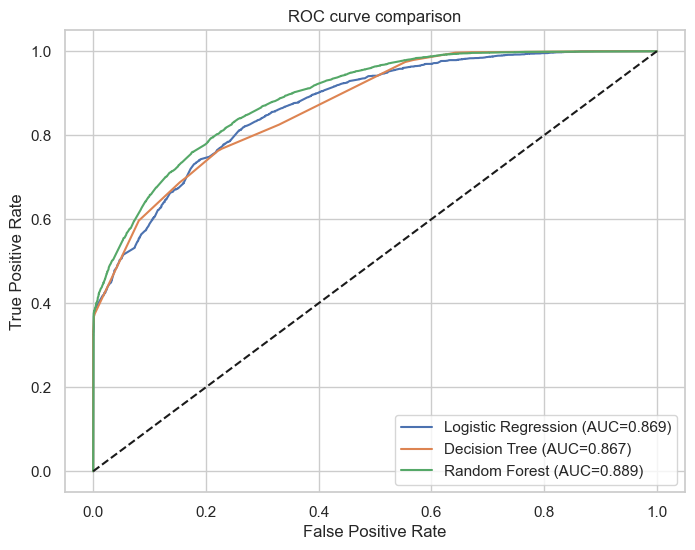

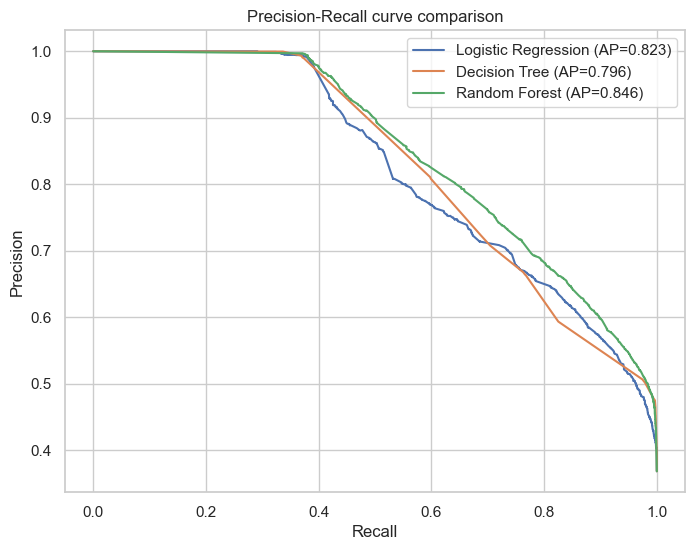

In [26]:
# Confusion matrix dan kurva evaluasi untuk baseline models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, baseline_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, prob in baseline_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
for name, prob in baseline_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
plt.title('Precision-Recall curve comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

### Cara kerja model dan batas kepercayaan model

Random Forest membangun banyak decision tree dari bootstrap sample yang berbeda, lalu menggabungkan hasilnya. Ini membuat model lebih stabil dibanding satu tree tunggal.

**Model bisa dipercaya ketika:**
- Pola data input mirip dengan data training
- Fitur yang dipakai tersedia lengkap
- Kebijakan hotel dan perilaku pelanggan tidak berubah drastis

**Model tidak boleh dipercaya penuh ketika:**
- Terjadi perubahan besar pada kebijakan deposit atau cancellation policy
- Ada pergeseran pola booking karena musim, event, atau shock pasar
- Banyak field penting hilang atau kategori baru muncul terus-menerus

## Model Improvement

Setelah baseline dibandingkan, kita lakukan hyperparameter tuning pada Random Forest.

### Kenapa tuning Random Forest?
- Dari tiga baseline, Random Forest paling cocok untuk data campuran ini.
- Parameter seperti `max_depth`, `min_samples_leaf`, dan `n_estimators` memengaruhi overfitting dan kemampuan menangkap pola cancel.
- Bayesian search merupakan trade-off yang seimbang antara exploration (try new data) dan exploitation (focus on promising ones).

### Kenapa scoring F1?
Recall adalah metrics utama dalam konteks masalah ini. Tapi bagaimanapun, pemilihan scoring tetap tergantung pada kebijakan hotel, yakni dengan melihat jenis mitigasi apa yang akan dilakukan.
Jika mitigasi bersifat follow-up, maka recall bisa digunakan karena minim *customer annoyance*.
Namun jika mitigasi bersifat perbedaan policy (misal kewajiban deposit, penyesuaian harga, dll), maka precision tetap perlu dipertimbangkan untuk menjaga kenyamanan tamu yang berpotensi False-positive.
Oleh karena itu, F1 lebih aman untuk digunakan saat tuning agar model tidak terlalu agresif menandai cancel dan tetap menjaga precision yang layak.

In [27]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

search_spaces = {
    'model__n_estimators': Integer(100, 500),
    'model__max_depth': Categorical([None] + list(range(3, 21))),
    'model__min_samples_split': Integer(2, 20),
    'model__min_samples_leaf': Integer(1, 10),
    'model__max_features': Categorical(['sqrt', 'log2', 0.5])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=rf_pipeline,
    search_spaces=search_spaces,
    n_iter=32,  # number of iterations (controls speed vs performance)
    scoring='f1',
    refit=True,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

bayes_search.fit(x_train_us, y_train_us)

print('Best parameters:')
print(bayes_search.best_params_)
print('Best CV F1: {:.4f}'.format(bayes_search.best_score_))

best_model = bayes_search.best_estimator_
tuned_metrics, tuned_pred, tuned_prob = evaluate_model('Tuned Random Forest', best_model, x_test, y_test)

tuned_rf_summary = pd.DataFrame([{'model': 'Tuned Random Forest', **tuned_metrics}])

display(tuned_rf_summary)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Random Forest,0.796829,0.696637,0.794185,0.74222,0.892431,0.850474


,feature,importance
51,cat__deposit_type_Non Refund,0.246017
36,cat__country_PRT,0.132863
50,cat__deposit_type_No Deposit,0.107745
49,cat__market_segment_Online TA,0.097004
4,num__total_of_special_requests,0.096942
3,num__required_car_parking_spaces,0.069998
0,num__previous_cancellations,0.052622
55,cat__customer_type_Transient,0.034569
1,num__booking_changes,0.026025
48,cat__market_segment_Offline TA/TO,0.016082


feature_group
deposit     0.354506
country     0.174914
market      0.146047
total       0.096942
required    0.069998
previous    0.052622
customer    0.052076
booking     0.026025
reserved    0.021292
days        0.005577
Name: importance, dtype: float64

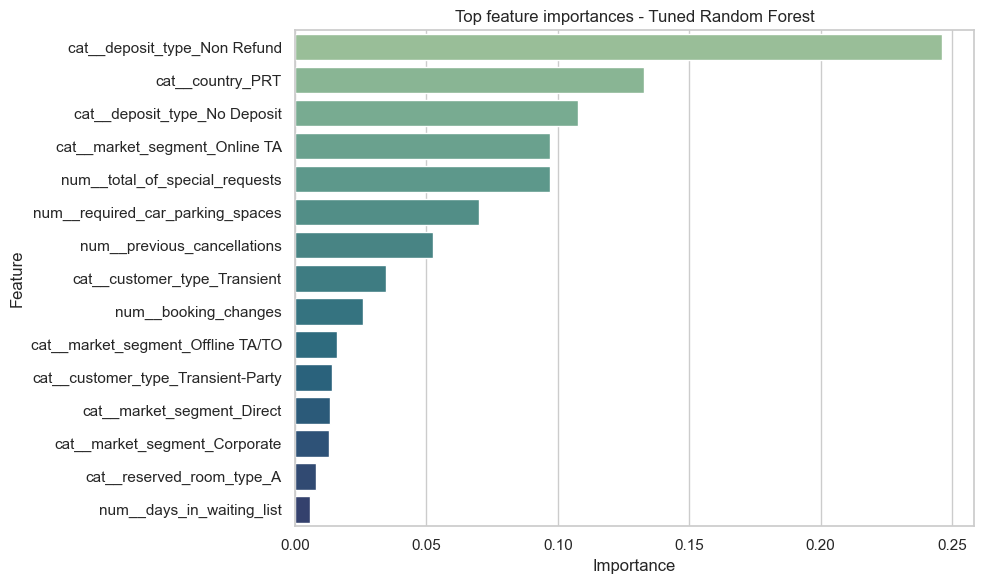

In [28]:
# Feature importance dari tuned Random Forest
preprocessor = best_model.named_steps['preprocess']
rf_model = best_model.named_steps['model']
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

importance_df['feature_group'] = importance_df['feature'].apply(
    lambda x: x.split('__')[1].split('_')[0]
)

grouped_importance = importance_df.groupby('feature_group')['importance']\
    .sum()\
    .sort_values(ascending=False)

display(grouped_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='crest')
plt.title('Top feature importances - Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Benchmarking dan pemilihan model terbaik

Model terbaik dipilih dengan logika bisnis berikut:
1. Recall pada kelas cancel sebagai prioritas utama.
2. F1-score sebagai penyeimbang precision dan recall.
3. PR AUC dan ROC AUC sebagai dukungan kualitas ranking.
4. Interpretabilitas dan stabilitas model.

Bila dua model memiliki performa yang mirip, model yang lebih sederhana dan lebih mudah dioperasikan akan lebih disukai.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.788573,0.680678,0.802307,0.736505,0.889496,0.846025
1,Tuned Random Forest,0.796829,0.696637,0.794185,0.742220,0.892431,0.850474
2,Decision Tree,0.771104,0.663992,0.766244,0.711463,0.867080,0.795832
3,Logistic Regression,0.776129,0.676410,0.751787,0.712110,0.868980,0.822943


Selected best model: Random Forest

Confusion matrix counts:
TN=8242, FP=2317, FN=1217, TP=4939
Flag rate: 43.41%
Potential manual review reduction: 56.59%
Recall on cancel class: 80.23%
Precision on cancel class: 68.07%


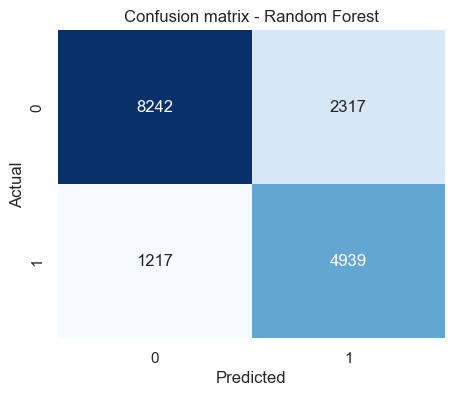

Classification report selected model:
              precision    recall  f1-score   support

           0     0.8713    0.7806    0.8235     10559
           1     0.6807    0.8023    0.7365      6156

    accuracy                         0.7886     16715
   macro avg     0.7760    0.7914    0.7800     16715
weighted avg     0.8011    0.7886    0.7914     16715



In [29]:
benchmark_df = pd.concat([
    baseline_df,
    tuned_rf_summary
], ignore_index=True)

benchmark_df = benchmark_df.sort_values(['recall', 'f1', 'pr_auc', 'accuracy'], ascending=False).reset_index(drop=True)
display(benchmark_df)

best_model_name = benchmark_df.iloc[0]['model']
print('Selected best model:', best_model_name)

model_bank = {
    'Logistic Regression': baseline_models['Logistic Regression'],
    'Decision Tree': baseline_models['Decision Tree'],
    'Random Forest': baseline_models['Random Forest'],
    'Tuned Random Forest': best_model
}

selected_model = model_bank[best_model_name]
selected_pred = selected_model.predict(x_test)
selected_prob = selected_model.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, selected_pred).ravel()
selected_recall = recall_score(y_test, selected_pred, zero_division=0)
selected_precision = precision_score(y_test, selected_pred, zero_division=0)
selected_flag_rate = selected_pred.mean()
selected_review_reduction = (1 - selected_flag_rate) * 100

print('\nConfusion matrix counts:')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print('Flag rate: {:.2f}%'.format(selected_flag_rate * 100))
print('Potential manual review reduction: {:.2f}%'.format(selected_review_reduction))
print('Recall on cancel class: {:.2f}%'.format(selected_recall * 100))
print('Precision on cancel class: {:.2f}%'.format(selected_precision * 100))

plot_confusion_matrix(y_test, selected_pred, f'Confusion matrix - {best_model_name}')

print('Classification report selected model:')
print(classification_report(y_test, selected_pred, digits=4, zero_division=0))

## Conclusion & Business Recommendation

### Final conclusion
Setelah melakukan Data Cleaning, Feature Engineering, Class Balancing, Modeling dan Hyperparameter Tuning, didapatkan bahwa model yang paling cocok digunakan adalah Random Forest. Hal ini karena Random Forest menunjukkan performa yang paling optimal dalam memprediksi kasus cancel, dimana presisi prediksinya pun yang paling stabil di antara Logistic Regression dan Decision Tree. Random Forest tetap dipilih dibandingkandengan Tuned Random Forest karena scoring Recall yang tetap lebih tinggi, dimana pada konteks business problem ini Recall menjadi metric yang paling utama dan precision menjadi metric pendukungnya.

### Output bisnis yang bisa diukur
- Dengan Random Forest, model dapat mendeteksi ±8 dari 10 tamu yang berpotensi cancel, dimana ±8 dari 10 cancel yang terdeteksi berpotensi benar.
- Nilai F1 sebesar 0.7365 menunjukkan bahwa model cukup konsisten dan mampu mendeteksi cancel dengan tetap menjaga akurasi alarmnya, sehingga setiap peringatan yang dikeluarkan memiliki tingkat kepercayaan yang tinggi.
- Nilai ROC-AUC 0.8895 membuktikan bahwa secara keseluruhan, model ini mampu memisahkan antara kasus cancel dan non-cancel.
- Nilai PR-AUC 0.8460, membuktikan bahwa walaupun dengan model fokus pada data cancel dan mengabaikan data non-cancel sekalipun, model tetap mampu memisahkan kasus cancel dan non-cancel dengan cukup baik.

### Cara pakai di workflow hotel
1. Score semua booking baru dengan model.
2. Prioritaskan follow-up untuk booking dengan risiko tertinggi.
3. Terapkan kebijakan tambahan seperti konfirmasi ulang atau deposit untuk segmen berisiko tinggi.
4. Monitor performa model setiap periode karena perilaku pelanggan bisa berubah.

### Kapan model layak dipakai
- Saat pola booking serupa dengan data training.
- Saat hotel membutuhkan early warning system untuk cancel risk.
- Saat input data lengkap dan kebijakan bisnis relatif stabil.

### Kapan model tidak layak dipakai
- Saat ada perubahan besar pada policy hotel.
- Saat distribusi pelanggan berubah drastis.
- Saat fitur penting tidak tersedia atau banyak data input yang tidak valid.

### Limitasi dan future improvement
- Dataset sample hanya sebagian dari dataset asli, sehingga hasil bisa berbeda pada full data.
- Tidak adanya unique identifier pada dataset sample, hal ini membuat data cleaning menjadi kurang maksimal karena proses `drop_duplicate` menjadi tidak applicable, memaksakan `drop_duplicate` berpotensi menghapus data asli yang sebenarnya bukan duplicate.
- Fitur yang tersedia masih terbatas. Variabel seperti lama menginap, waktu check-in dan waktu check-out, serta penggunaan voucher biasanya sangat membantu tapi tidak tersedia di sini.
- Untuk production, perlu evaluasi threshold, kalibrasi probabilitas, dan retraining berkala.
- Jika nanti tersedia data waktu, gunakan time-aware split agar evaluasi lebih realistis.

### Rekomendasi bisnis
- Gunakan model ini sebagai alat prioritisasi booking berisiko tinggi, bukan sebagai pengganti keputusan bisnis.
- Minimalisir penggunaan model saat hari-hari biasa dan bukan peak-season, terutama jika hotel tidak berpotensi over-book secara statistik.
- Model ini paling bernilai ketika digunakan untuk mengarahkan tim agar fokus pada booking yang paling mungkin dibatalkan, sehingga revenue protection dan efisiensi operasional meningkat.
- Menetapkan kebijakan mitigasi yang paling efisien, agar model bisa mengikuti kebijakan dan memilih scoring mana yang paling cocok.

# Save Model

In [30]:
joblib.dump(best_model, 'hotel_booking_demand_model.joblib')

['hotel_booking_demand_model.joblib']